## Used Car Price Prediction

In [1]:
import pandas as pd
import zipfile
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from io import BytesIO

In [2]:
url = "https://www.kaggle.com/api/v1/datasets/download/therohithanand/used-car-price-prediction"

response = requests.get(url)
zip_file = zipfile.ZipFile(BytesIO(response.content))
zip_file.namelist()

['used_car_price_dataset_extended.csv']

In [3]:
df = pd.read_csv(zip_file.open("used_car_price_dataset_extended.csv"))

In [4]:
df.head()

,make_year,mileage_kmpl,engine_cc,fuel_type,owner_count,price_usd,brand,transmission,color,service_history,accidents_reported,insurance_valid
0,2001,8.17,4000,Petrol,4,8587.64,Chevrolet,Manual,White,NaN,0,No
1,2014,17.59,1500,Petrol,4,5943.50,Honda,Manual,Black,NaN,0,Yes
2,2023,18.09,2500,Diesel,5,9273.58,BMW,Automatic,Black,Full,1,Yes
3,2009,11.28,800,Petrol,1,6836.24,Hyundai,Manual,Blue,Full,0,Yes
4,2005,12.23,1000,Petrol,2,4625.79,Nissan,Automatic,Red,Full,0,Yes


In [5]:
df.shape

(10000, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   make_year           10000 non-null  int64  
 1   mileage_kmpl        10000 non-null  float64
 2   engine_cc           10000 non-null  int64  
 3   fuel_type           10000 non-null  object 
 4   owner_count         10000 non-null  int64  
 5   price_usd           10000 non-null  float64
 6   brand               10000 non-null  object 
 7   transmission        10000 non-null  object 
 8   color               10000 non-null  object 
 9   service_history     7962 non-null   object 
 10  accidents_reported  10000 non-null  int64  
 11  insurance_valid     10000 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 937.6+ KB


In [7]:
df.iloc[0]

make_year                  2001
mileage_kmpl               8.17
engine_cc                  4000
fuel_type                Petrol
owner_count                   4
price_usd               8587.64
brand                 Chevrolet
transmission             Manual
color                     White
service_history             NaN
accidents_reported            0
insurance_valid              No
Name: 0, dtype: object

In [8]:
df.isna().sum()

make_year                0
mileage_kmpl             0
engine_cc                0
fuel_type                0
owner_count              0
price_usd                0
brand                    0
transmission             0
color                    0
service_history       2038
accidents_reported       0
insurance_valid          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe()

,make_year,mileage_kmpl,engine_cc,owner_count,price_usd,accidents_reported
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,2009.206900,17.960753,2287.130000,3.003500,7179.754532,0.492200
std,8.373858,5.025486,1291.276927,1.418904,2795.270940,0.694109
min,1995.000000,5.000000,800.000000,1.000000,1000.000000,0.000000
25%,2002.000000,14.540000,1200.000000,2.000000,5176.547500,0.000000
50%,2009.000000,17.970000,1800.000000,3.000000,6961.260000,0.000000
75%,2016.000000,21.352500,3000.000000,4.000000,8993.732500,1.000000
max,2023.000000,35.000000,5000.000000,5.000000,17647.630000,5.000000


In [11]:
df.describe(include="object")

,fuel_type,brand,transmission,color,service_history,insurance_valid
count,10000,10000,10000,10000,7962,10000
unique,3,10,2,6,2,2
top,Petrol,Nissan,Manual,Gray,Full,Yes
freq,4968,1089,5985,1705,4987,7934


In [12]:
df.nunique().sort_values(ascending=False)

price_usd             9906
mileage_kmpl          2213
make_year               29
engine_cc               10
brand                   10
color                    6
accidents_reported       6
owner_count              5
fuel_type                3
transmission             2
service_history          2
insurance_valid          2
dtype: int64

In [13]:
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
numeric_columns

Index(['make_year', 'mileage_kmpl', 'engine_cc', 'owner_count', 'price_usd',
       'accidents_reported'],
      dtype='object')

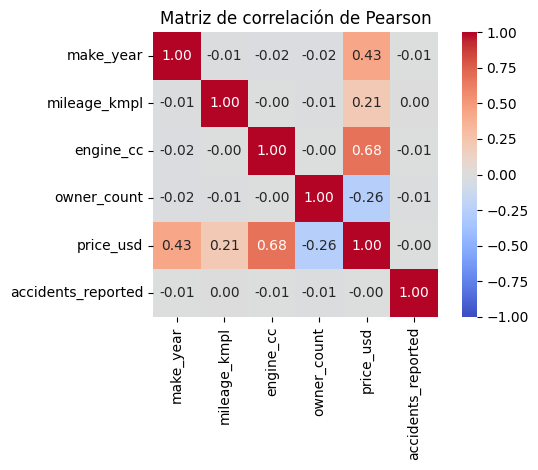

In [14]:
corr_matrix = df[numeric_columns].corr()

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de correlación de Pearson')
plt.tight_layout()
plt.show()